##STC TV User Behavior Forecasting Model

Objective

Build a simple forecasting model to predict expected customer watch behavior for the next two months and identify possible peak usage periods.


In [195]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [196]:
#read the excel file
df = pd.read_excel('/content/stc TV Data Set_T2.xlsx')
print(df.head().to_string(index=False))

 Unnamed: 0      date_  Total_watch_time_in_houres
          0 2018-01-01                 1123.551944
          1 2018-01-02                 1000.129722
          2 2018-01-03                  881.924444
          3 2018-01-04                  782.669444
          4 2018-01-05                 1051.939444


In [197]:
df = df.drop(columns=['Unnamed: 0'])

In [198]:
#convert date olumn
df['date_'] = pd.to_datetime(df['date_'])

In [199]:
#create day numbers to help the machine learning understand
df['day_num'] = np.arange(len(df))
print(df.head().to_string(index=False))

     date_  Total_watch_time_in_houres  day_num
2018-01-01                 1123.551944        0
2018-01-02                 1000.129722        1
2018-01-03                  881.924444        2
2018-01-04                  782.669444        3
2018-01-05                 1051.939444        4


In [200]:
#defining the X and Y
X = df[['day_num']]
y = df['Total_watch_time_in_houres']

In [201]:
#create linear regression model
model = LinearRegression()

In [202]:
#teach model using historical data
model.fit(X, y)

LinearRegression()

In [203]:
#predict next 60 days
future_days = pd.DataFrame({
    'day_num': np.arange(len(df), len(df) + 60)})

#predict watch hours
predictions = model.predict(future_days)

In [204]:
#create future dates
future_dates = pd.date_range(
    start=df['date_'].max() + pd.Timedelta(days=1),
    periods=60)

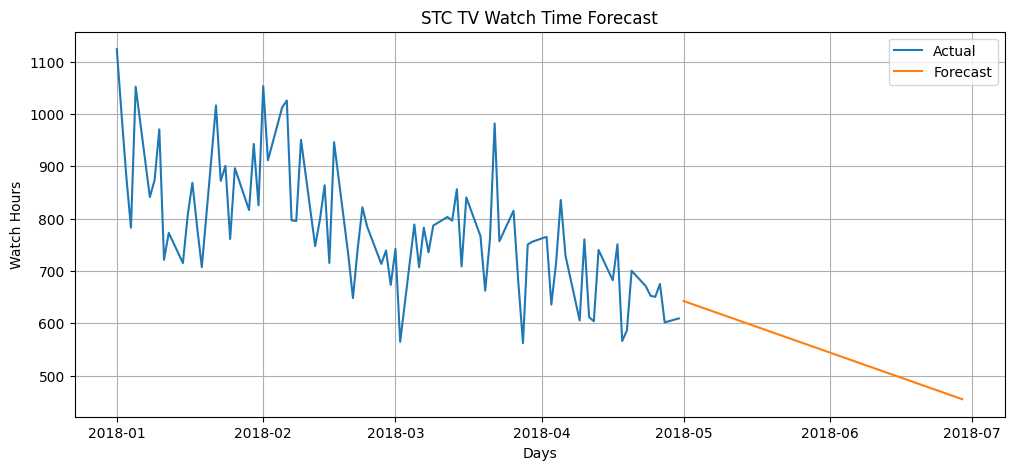

In [205]:
#plot Actual vs Forecast
plt.figure(figsize=(12,5))
plt.plot(df['date_'], y, label='Actual')
plt.plot(future_dates, predictions, label='Forecast')
plt.title("STC TV Watch Time Forecast")
plt.xlabel("Days")
plt.ylabel("Watch Hours")
plt.legend()
plt.grid(True)
plt.show()

In [206]:
#top 10 highest watch-time days
peak_days = df.sort_values(
    'Total_watch_time_in_houres',
    ascending=False
).head(10)
print(peak_days.to_string(index=False))

     date_  Total_watch_time_in_houres  day_num
2018-01-01                 1123.551944        0
2018-02-01                 1053.168611       23
2018-01-05                 1051.939444        4
2018-02-06                 1025.595556       26
2018-01-22                 1016.186667       15
2018-02-05                 1012.082222       25
2018-01-02                 1000.129722        1
2018-03-22                  981.626944       58
2018-01-10                  970.475000        7
2018-02-09                  950.520000       29


The Linear Regression model indicates a downward trend in total watch time over the next two months.

Peak usage was identified on the highest watch-time dates, which may help optimize promotions and server planning.